# 2 - Isolation Forest vs autoencoder

This notebook reads the artifacts written by `scripts/03_train_models.py` rather than
retraining, so it runs in seconds and always reflects the numbers shipped in
`results/`.

Both detectors see the identical feature matrix, are fitted on the identical rows, and
are held to the identical alert budget. Any difference between them is the algorithm,
not the setup.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 100, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

In [2]:
import json
from dq_anomaly.config import PATHS

payload = json.loads((PATHS.metrics / "model_comparison.json").read_text())
scores_archive = np.load(PATHS.metrics / "test_scores.npz")
y_test = scores_archive["y_test"]

print("Split      :", payload["split"])
print("Threshold  :", payload["headline_threshold"])
print(f"Test window: {len(y_test):,} transactions, {int(y_test.sum())} frauds "
      f"({y_test.mean():.4%})")

Split      : temporal 60/20/20 (train / calibration / test)
Threshold  : budget@0.50% set on the unlabelled calibration window
Test window: 56,962 transactions, 75 frauds (0.1317%)


## The evaluation protocol

Three things here are deliberate and are what separate an honest result from a
flattering one.

**The split is temporal, not random.** The data is two consecutive days, so the models
are fitted on the earlier 60%, the threshold is calibrated on the next 20%, and the
final 20% is scored exactly once. This is the real task: fit on history, score the
batch that arrives next.

**The scaler is fitted on the training rows only.** Fitting it on the full dataset
leaks the anomalies into the definition of normal, and it is the single most common
source of inflated numbers on this dataset.

**The threshold uses no labels.** It is the 99.5th percentile of the *unlabelled*
calibration window, i.e. "flag as much as a reviewer can clear". The label-optimal
threshold is computed too, but only as an upper bound, and it is marked as an oracle
everywhere it appears.

In [3]:
table = pd.read_csv(PATHS.metrics / "model_comparison.csv")
display_cols = ["model", "pr_auc", "roc_auc", "precision", "recall", "f1",
                "alerts", "true_positives", "false_positives"]
table[display_cols].round(4)

,model,pr_auc,roc_auc,precision,recall,f1,alerts,true_positives,false_positives
0,Logistic Regression (supervised ceiling),0.7780,0.9814,0.2278,0.8533,0.3596,281,64,217
1,Autoencoder (trained on normals),0.2873,0.9204,0.2523,0.7200,0.3737,214,54,160
2,Isolation Forest (trained on normals),0.0898,0.9492,0.1496,0.4667,0.2265,234,35,199
3,Autoencoder (fully unsupervised),0.0852,0.9437,0.1628,0.2800,0.2059,129,21,108
4,Isolation Forest (fully unsupervised),0.0759,0.9490,0.1231,0.3200,0.1778,195,24,171
5,Random (floor),0.0012,0.4618,0.0000,0.0000,0.0000,291,0,291


## Why PR-AUC is the headline and ROC-AUC is not

Look at the two baselines in the table above. Isolation Forest reports a **higher**
ROC-AUC than the autoencoder, yet catches far fewer frauds at the same alert budget.

That is not a contradiction, it is what ROC-AUC does at 0.17% prevalence. ROC-AUC is
dominated by the 56,000 negatives: moving ten thousand false positives from rank
50,000 down to rank 200,000 barely moves the false positive rate. But it completely
changes what a reviewer sees at the top of the queue, and the top of the queue *is* the
product. PR-AUC is the metric that degrades when the top of the ranking fills with
negatives.

In [4]:
prevalence = float(y_test.mean())
comparison = table.set_index("model")[["roc_auc", "pr_auc"]].copy()
comparison["pr_auc_lift_vs_random"] = (comparison["pr_auc"] / prevalence).round(1)

print(f"A random ranker scores ROC-AUC 0.500 but PR-AUC {prevalence:.4f}\n")
print(comparison.round(4).to_string())

A random ranker scores ROC-AUC 0.500 but PR-AUC 0.0013

                                          roc_auc  pr_auc  pr_auc_lift_vs_random
model                                                                           
Logistic Regression (supervised ceiling)   0.9814  0.7780                  590.9
Autoencoder (trained on normals)           0.9204  0.2873                  218.2
Isolation Forest (trained on normals)      0.9492  0.0898                   68.2
Autoencoder (fully unsupervised)           0.9437  0.0852                   64.7
Isolation Forest (fully unsupervised)      0.9490  0.0759                   57.7
Random (floor)                             0.4618  0.0012                    0.9


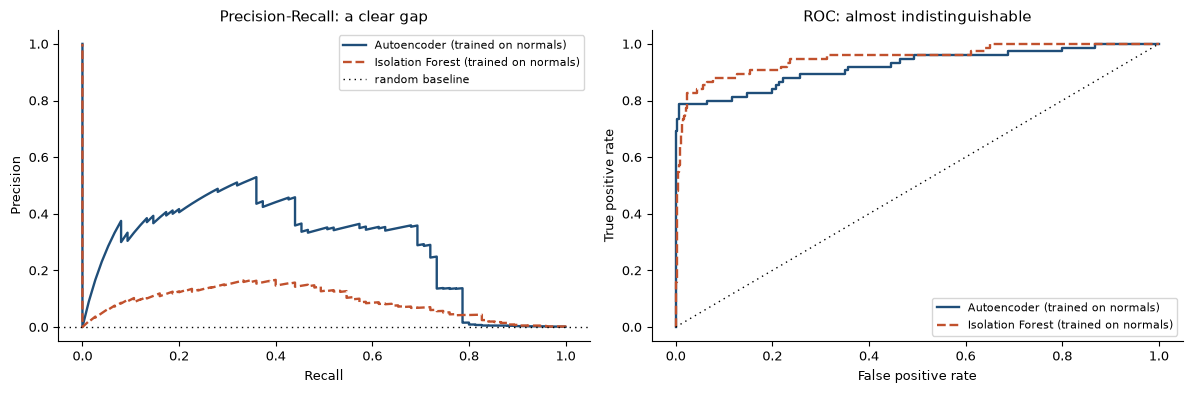

In [5]:
from sklearn.metrics import precision_recall_curve, roc_curve

ae_key = "Autoencoder_(trained_on_normals)"
if_key = "Isolation_Forest_(trained_on_normals)"

fig, (pr_ax, roc_ax) = plt.subplots(1, 2, figsize=(12, 4))
for key, colour, style in ((ae_key, "#1f4e79", "-"), (if_key, "#c1512d", "--")):
    p, r, _ = precision_recall_curve(y_test, scores_archive[key])
    pr_ax.plot(r, p, style, color=colour, linewidth=1.7, label=key.replace("_", " "))
    fpr, tpr, _ = roc_curve(y_test, scores_archive[key])
    roc_ax.plot(fpr, tpr, style, color=colour, linewidth=1.7, label=key.replace("_", " "))

pr_ax.axhline(prevalence, color="black", linestyle=(0, (1, 3)), linewidth=1,
              label="random baseline")
pr_ax.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall: a clear gap")
pr_ax.legend(fontsize=8)
roc_ax.plot([0, 1], [0, 1], color="black", linestyle=(0, (1, 3)), linewidth=1)
roc_ax.set(xlabel="False positive rate", ylabel="True positive rate",
           title="ROC: almost indistinguishable")
roc_ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()

## Is the gap larger than the noise?

In [6]:
for name in ["Autoencoder (trained on normals)", "Isolation Forest (trained on normals)"]:
    metrics = payload["results"][name]
    low, high = metrics["pr_auc_ci95"]
    r_low, r_high = metrics["recall_ci95"]
    print(f"{name:42s} PR-AUC {metrics['pr_auc']:.3f} [{low:.3f}, {high:.3f}]  "
          f"recall {metrics['recall']:.3f} [{r_low:.3f}, {r_high:.3f}]")

print("\nThe bootstrap intervals do not overlap, so with only ~75 frauds in the test")
print("window the difference between the two models is still larger than the noise.")

Autoencoder (trained on normals)           PR-AUC 0.287 [0.189, 0.396]  recall 0.720 [0.603, 0.800]
Isolation Forest (trained on normals)      PR-AUC 0.090 [0.058, 0.132]  recall 0.467 [0.354, 0.583]

The bootstrap intervals do not overlap, so with only ~75 frauds in the test
window the difference between the two models is still larger than the noise.


## The cost of the oracle threshold

Reporting the label-optimal threshold as if it were achievable is the most common
overstatement in unsupervised fraud write-ups. Here is the size of the overstatement.

In [7]:
rows = []
for name in payload["results"]:
    honest = payload["results"][name]
    extra = payload["oracle_and_sweeps"].get(name, {}).get("oracle_best_f1")
    if extra is None:
        continue
    rows.append({
        "model": name,
        "f1_budget_threshold": round(honest["f1"], 4),
        "f1_oracle_threshold": round(extra["f1"], 4),
        "overstatement": round(extra["f1"] - honest["f1"], 4),
    })
pd.DataFrame(rows)

,model,f1_budget_threshold,f1_oracle_threshold,overstatement
0,Autoencoder (trained on normals),0.3737,0.4727,0.0990
1,Autoencoder (fully unsupervised),0.2059,0.2249,0.0190
2,Isolation Forest (trained on normals),0.2265,0.2353,0.0088
3,Isolation Forest (fully unsupervised),0.1778,0.1988,0.0211


## Translating false positives into staffing

In [8]:
sweep = payload["oracle_and_sweeps"]["Autoencoder (trained on normals)"]["budget_sweep"]
workload = pd.DataFrame([{
    "review_budget": f"{entry['flag_rate']:.2%}",
    "alerts": entry["alerts"],
    "review_hours": round(entry["review_hours"], 1),
    "frauds_caught": entry["true_positives"],
    "frauds_missed": entry["false_negatives"],
    "recall": round(entry["recall"], 3),
    "precision": round(entry["precision"], 3),
} for entry in sweep])
workload

,review_budget,alerts,review_hours,frauds_caught,frauds_missed,recall,precision
0,0.10%,59,1.5,27,48,0.360,0.458
1,0.38%,214,5.3,54,21,0.720,0.252
2,0.79%,448,11.2,59,16,0.787,0.132
3,1.54%,879,22.0,59,16,0.787,0.067


Every extra percentage point of review budget buys recall at a worsening rate.
That table is the conversation a data quality team actually has with its business
owner: not "what is the F1 score" but "how many people do we need, and how much fraud
do we accept losing".

## The two things the autoencoder gives you that Isolation Forest does not

In [9]:
from dq_anomaly.anomaly.artifacts import load_bundle
from dq_anomaly.anomaly.preprocess import temporal_split
from dq_anomaly.data.loaders import load_creditcard

bundle = load_bundle()
_, _, test = temporal_split(load_creditcard())
X_test = bundle.preprocessor.transform(test)
errors = bundle.autoencoder.per_feature_errors(X_test)
recon = bundle.autoencoder.reconstruct(X_test)
scores = errors.mean(axis=1)

worst = int(np.argmax(scores))
top = np.argsort(-errors[worst])[:5]
print(f"Highest-scoring record in the test window (actual label: "
      f"{'FRAUD' if test['Class'].to_numpy()[worst] else 'legitimate'})\n")
for i in top:
    name = bundle.feature_names[i]
    print(f"  {name:12s} observed {X_test[worst, i]:8.2f}   "
          f"model expected {recon[worst, i]:7.2f}   "
          f"{errors[worst, i] / errors[worst].sum():5.1%} of the error")

Highest-scoring record in the test window (actual label: legitimate)

  V27          observed    81.91   model expected   46.31   29.5% of the error
  log_amount   observed     4.24   model expected   30.96   16.6% of the error
  V28          observed   -50.36   model expected  -25.17   14.8% of the error
  V3           observed   -38.25   model expected  -58.03    9.1% of the error
  V1           observed   -19.65   model expected  -35.52    5.9% of the error


The first advantage is above: a reconstruction error decomposes per feature, so a
flagged record comes with *which fields* made it unusual. Isolation Forest returns a
score and nothing else. That decomposition is what turns an alert into an issue a
reviewer can act on, and it is why the autoencoder is the production model here even
where the metric gap is modest.

The second is the training curve: the model can be monitored, retrained and versioned
like any other, and the validation loss tells you when it has stopped learning
normality and started memorising it.

Note: training further does not help. Pushing the ceiling from 150 to 400 epochs
lowered reconstruction loss but reduced PR-AUC from 0.287 to 0.280, because the
model starts reconstructing the anomalies too. Lower loss is not the objective.


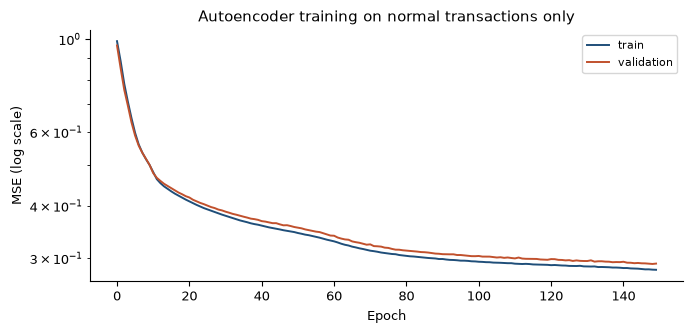

In [10]:
history = payload["autoencoder_history"]
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(history["train_loss"], color="#1f4e79", linewidth=1.4, label="train")
ax.plot(history["val_loss"], color="#c1512d", linewidth=1.4, label="validation")
ax.set(xlabel="Epoch", ylabel="MSE (log scale)", yscale="log",
       title="Autoencoder training on normal transactions only")
ax.legend(fontsize=8)
plt.tight_layout()

print("Note: training further does not help. Pushing the ceiling from 150 to 400 epochs")
print("lowered reconstruction loss but reduced PR-AUC from 0.287 to 0.280, because the")
print("model starts reconstructing the anomalies too. Lower loss is not the objective.")